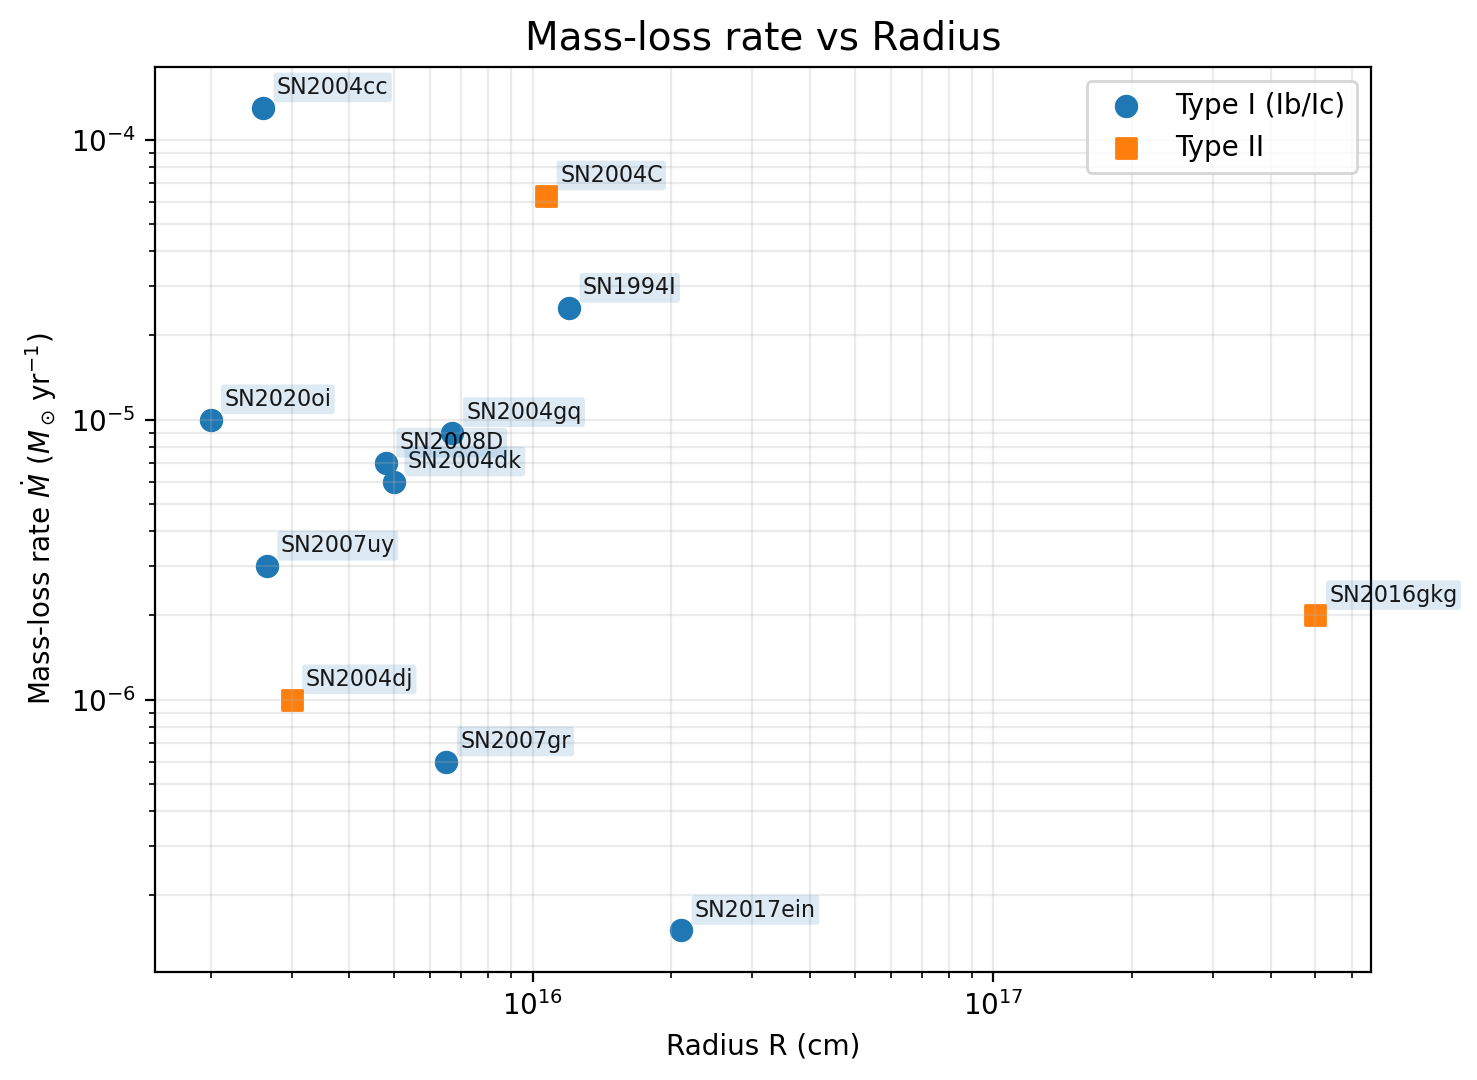

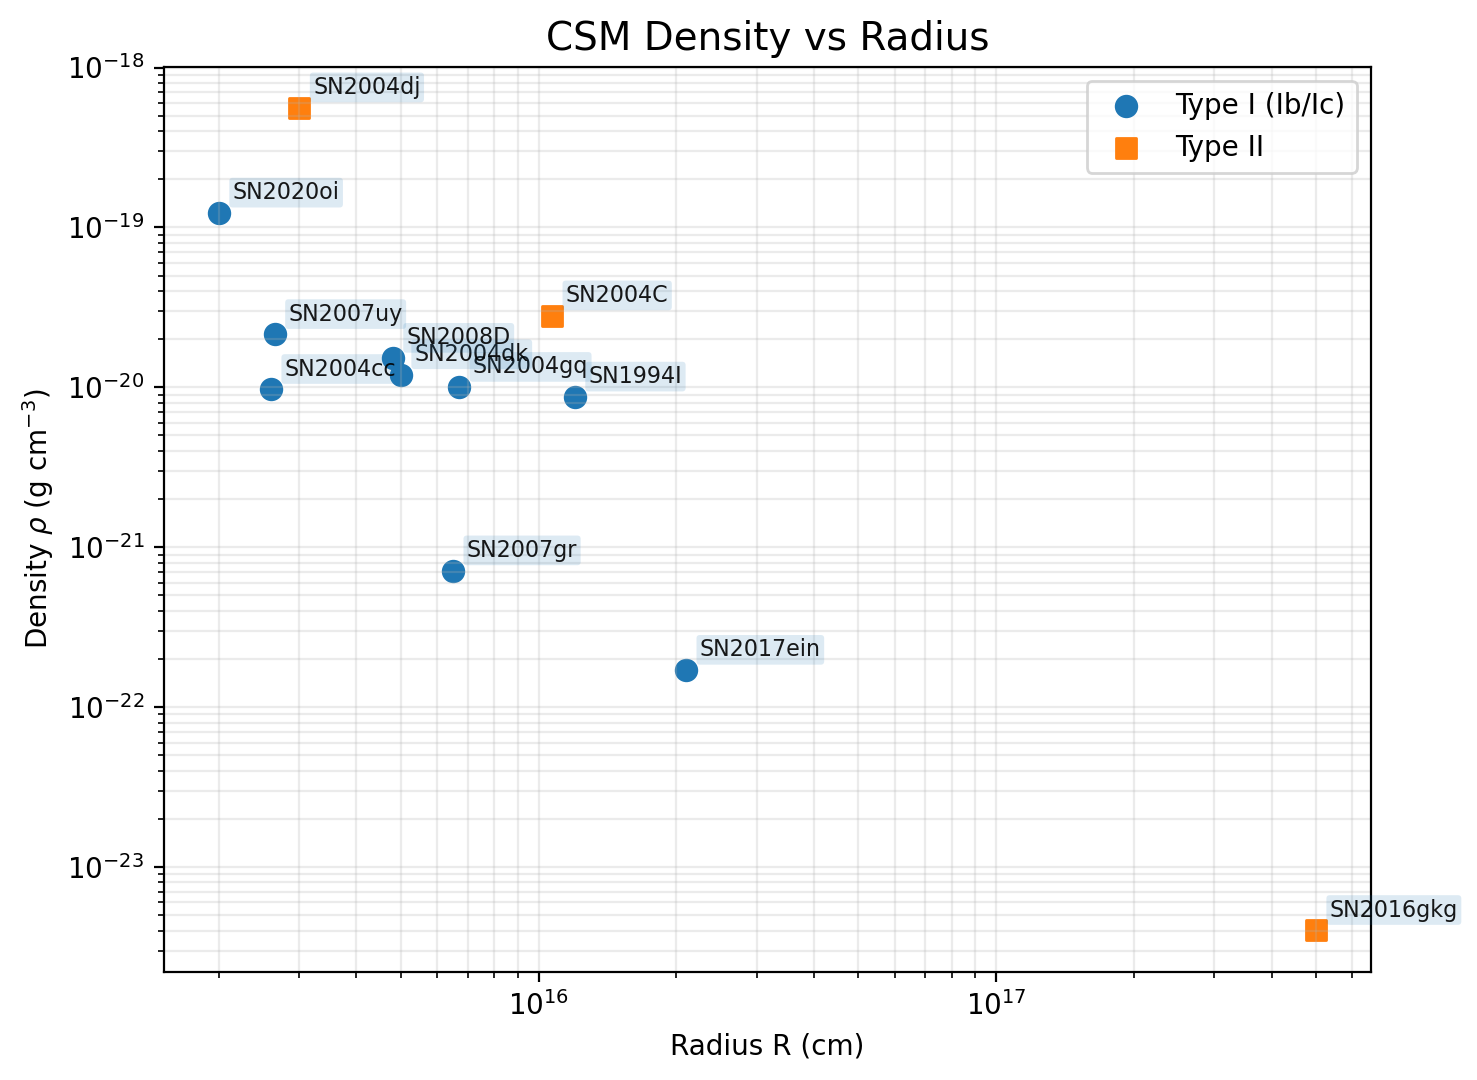

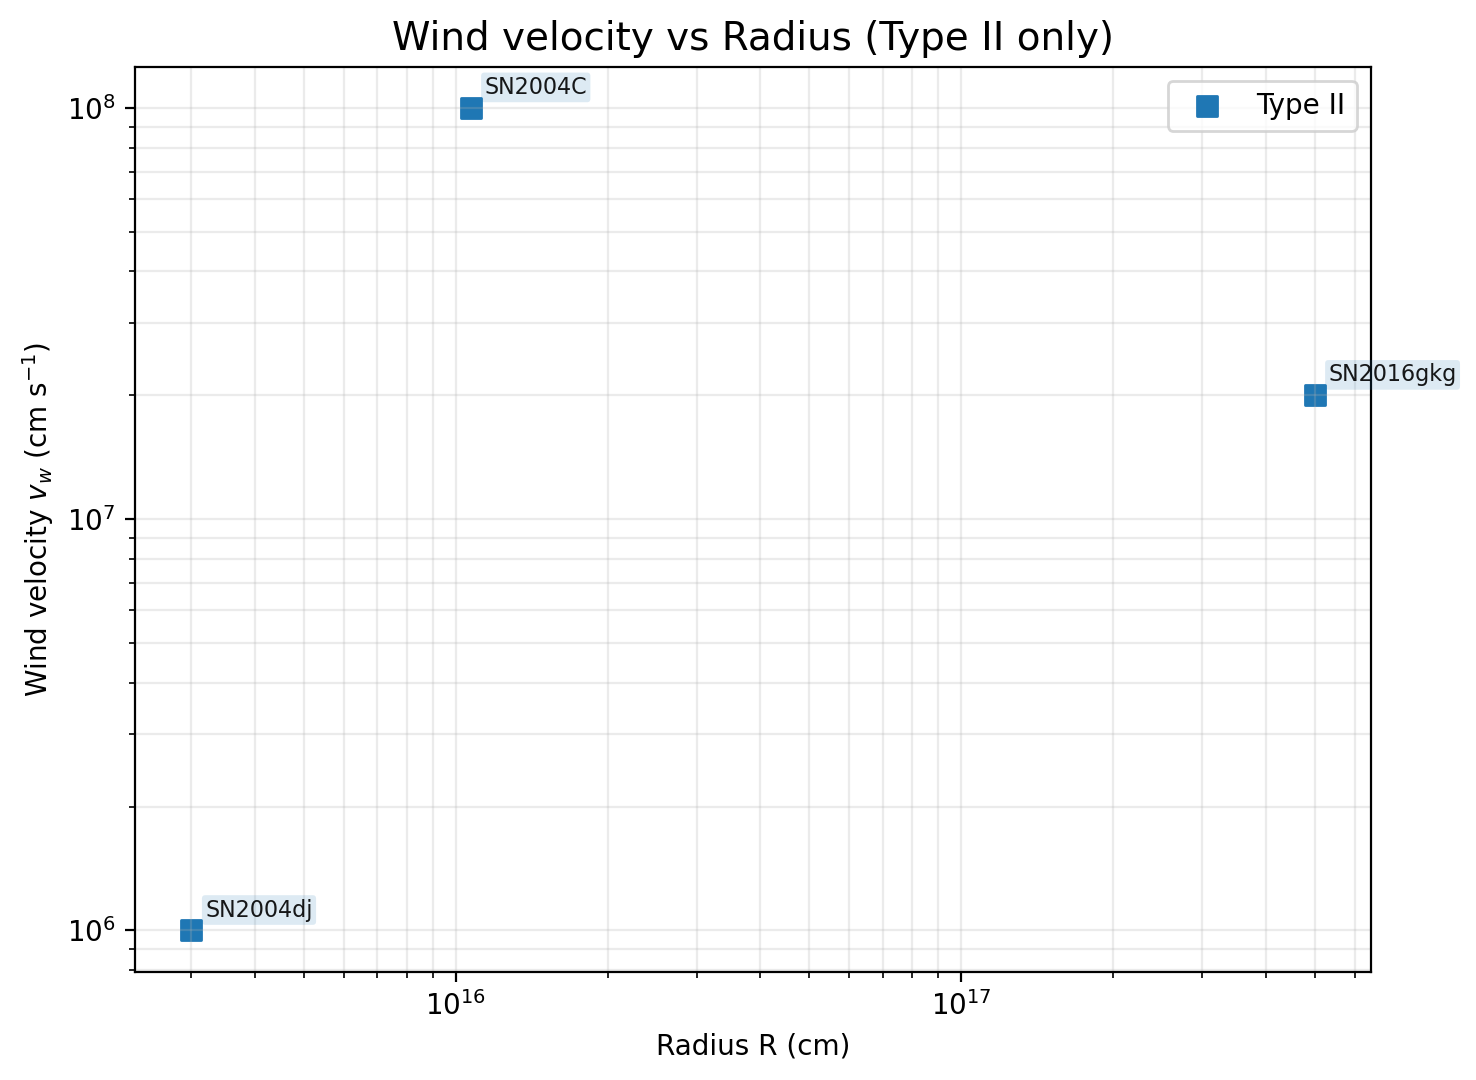

Saved figures:
 - mass_loss_vs_radius.png
 - density_vs_radius.png
 - wind_velocity_vs_radius_typeII.png


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Data keyed from your table (EP rows only where requested)
# Units:
#   R: cm
#   rho: g/cm^3
#   Mdot: Msun/yr
#   vw: cm/s
# Notes:
#   - Ib/Ic wind speeds are mostly identical in your table, so vw-plot uses only Type II (per your instruction).
#   - Blank fields are left as None and filtered out per-plot.
# -----------------------------
data = [
    # Type II (includes IIb, IIP)
    {"name": "SN2004C",   "group": "Type II", "subtype": "IIb", "R": 1.07e16, "rho": 2.8e-20, "Mdot": 6.3e-5, "vw": 1.0e8},
    {"name": "SN2016gkg", "group": "Type II", "subtype": "IIb", "R": 5.00e17, "rho": 4.01e-24, "Mdot": 2.0e-6, "vw": 0.2e8},
    {"name": "SN2004dj",  "group": "Type II", "subtype": "IIP", "R": 3.00e15, "rho": 5.6e-19, "Mdot": 1.0e-6, "vw": 1.0e6},

    # Type I (Ib/Ic grouped together)
    {"name": "SN2017ein", "group": "Type I (Ib/Ic)", "subtype": "Ic", "R": 2.10e16, "rho": 1.7e-22,  "Mdot": 1.5e-7, "vw": 1.0e8},
    {"name": "SN1994I",   "group": "Type I (Ib/Ic)", "subtype": "Ic", "R": 1.20e16, "rho": 8.7e-21,  "Mdot": 2.5e-5, "vw": None},
    {"name": "SN2004cc",  "group": "Type I (Ib/Ic)", "subtype": "Ic", "R": 2.60e15, "rho": 9.7e-21,  "Mdot": 1.3e-4, "vw": None},
    {"name": "SN2004gq",  "group": "Type I (Ib/Ic)", "subtype": "Ib", "R": 6.70e15, "rho": 1.0e-20,  "Mdot": 9.0e-6, "vw": None},
    {"name": "SN2004dk",  "group": "Type I (Ib/Ic)", "subtype": "Ib", "R": 5.00e15, "rho": 1.2e-20,  "Mdot": 6.0e-6, "vw": None},
    {"name": "SN2008D",   "group": "Type I (Ib/Ic)", "subtype": "Ib", "R": 4.80e15, "rho": 1.52e-20, "Mdot": 7.0e-6, "vw": None},
    {"name": "SN2007uy",  "group": "Type I (Ib/Ic)", "subtype": "Ib", "R": 2.65e15, "rho": 2.14e-20, "Mdot": 3.0e-6, "vw": None},
    {"name": "SN2007gr",  "group": "Type I (Ib/Ic)", "subtype": "Ic", "R": 6.50e15, "rho": 7.12e-22, "Mdot": 6.0e-7, "vw": None},
    {"name": "SN2020oi",  "group": "Type I (Ib/Ic)", "subtype": "Ic", "R": 2.00e15, "rho": 1.23e-19, "Mdot": 1.0e-5, "vw": None},
]

# Plot styling: group colors/markers
STYLE = {
    "Type I (Ib/Ic)": {"marker": "o", "label": "Type I (Ib/Ic)"},
    "Type II":        {"marker": "s", "label": "Type II"},
}

def filter_rows(x_key, y_key, group_filter=None):
    rows = []
    for d in data:
        if group_filter is not None and d["group"] not in group_filter:
            continue
        x = d.get(x_key, None)
        y = d.get(y_key, None)
        if x is None or y is None:
            continue
        rows.append(d)
    return rows

def add_labels(ax, rows, x_key, y_key, frac_offset=0.03):
    # simple, robust label placement (small offset in log space)
    xs = np.array([r[x_key] for r in rows], dtype=float)
    ys = np.array([r[y_key] for r in rows], dtype=float)
    for r, x, y in zip(rows, xs, ys):
        ax.annotate(
            r["name"],
            (x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8,
            alpha=0.9,
            bbox=dict(boxstyle="round,pad=0.15", alpha=0.15, linewidth=0)
        )

def scatter_by_group(ax, rows, x_key, y_key):
    for grp in ["Type I (Ib/Ic)", "Type II"]:
        grp_rows = [r for r in rows if r["group"] == grp]
        if not grp_rows:
            continue
        xs = [r[x_key] for r in grp_rows]
        ys = [r[y_key] for r in grp_rows]
        ax.scatter(xs, ys, s=55, marker=STYLE[grp]["marker"], label=STYLE[grp]["label"])
    add_labels(ax, rows, x_key, y_key)

def finish_axes(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.grid(True, which="both", alpha=0.25)
    ax.legend(frameon=True)

# -----------------------------
# 1) Mass-loss rate vs radius (Type I vs Type II)
# -----------------------------
rows_mdot = filter_rows("R", "Mdot", group_filter={"Type I (Ib/Ic)", "Type II"})
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=200)
scatter_by_group(ax, rows_mdot, "R", "Mdot")
finish_axes(
    ax,
    title="Mass-loss rate vs Radius",
    xlabel="Radius R (cm)",
    ylabel=r"Mass-loss rate $\dot{M}$ ($M_\odot\,\mathrm{yr}^{-1}$)"
)
fig.tight_layout()
plt.show()
fig.savefig("mass_loss_vs_radius.png", bbox_inches="tight")
plt.close(fig)

# -----------------------------
# 2) Density vs radius (Type I vs Type II)
# -----------------------------
rows_rho = filter_rows("R", "rho", group_filter={"Type I (Ib/Ic)", "Type II"})
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=200)
scatter_by_group(ax, rows_rho, "R", "rho")
finish_axes(
    ax,
    title="CSM Density vs Radius",
    xlabel="Radius R (cm)",
    ylabel=r"Density $\rho$ (g cm$^{-3}$)"
)
fig.tight_layout()
plt.show()
fig.savefig("density_vs_radius.png", bbox_inches="tight")
plt.close(fig)

# -----------------------------
# 3) Wind velocity vs radius (ONLY Type II, per your instruction)
# -----------------------------
rows_vw = filter_rows("R", "vw", group_filter={"Type II"})
fig, ax = plt.subplots(figsize=(7.5, 5.5), dpi=200)

# Single group here (Type II)
xs = [r["R"] for r in rows_vw]
ys = [r["vw"] for r in rows_vw]
ax.scatter(xs, ys, s=55, marker=STYLE["Type II"]["marker"], label="Type II")
add_labels(ax, rows_vw, "R", "vw")

finish_axes(
    ax,
    title="Wind velocity vs Radius (Type II only)",
    xlabel="Radius R (cm)",
    ylabel=r"Wind velocity $v_w$ (cm s$^{-1}$)"
)
fig.tight_layout()
plt.show()
fig.savefig("wind_velocity_vs_radius_typeII.png", bbox_inches="tight")
plt.close(fig)

print("Saved figures:")
print(" - mass_loss_vs_radius.png")
print(" - density_vs_radius.png")
print(" - wind_velocity_vs_radius_typeII.png")


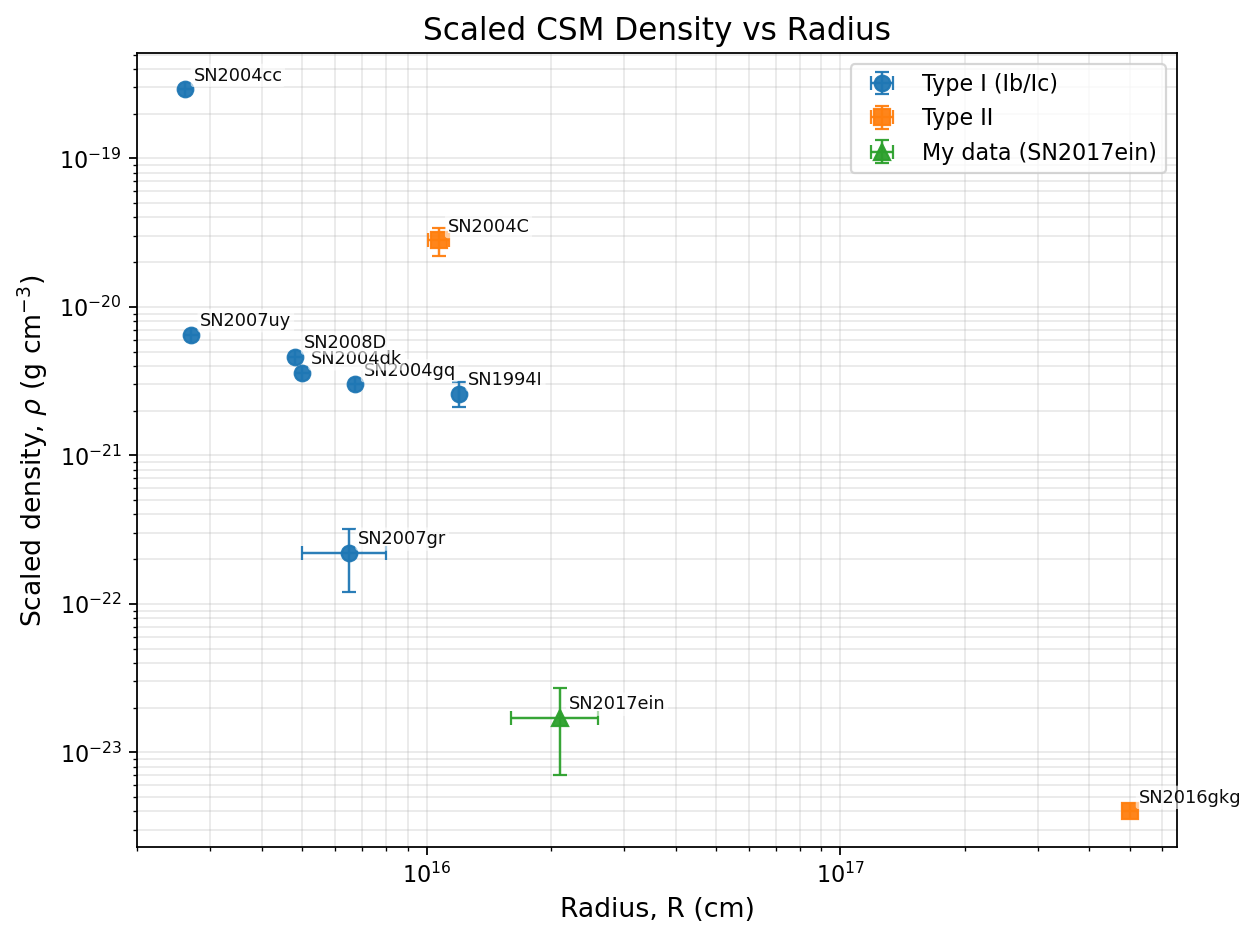

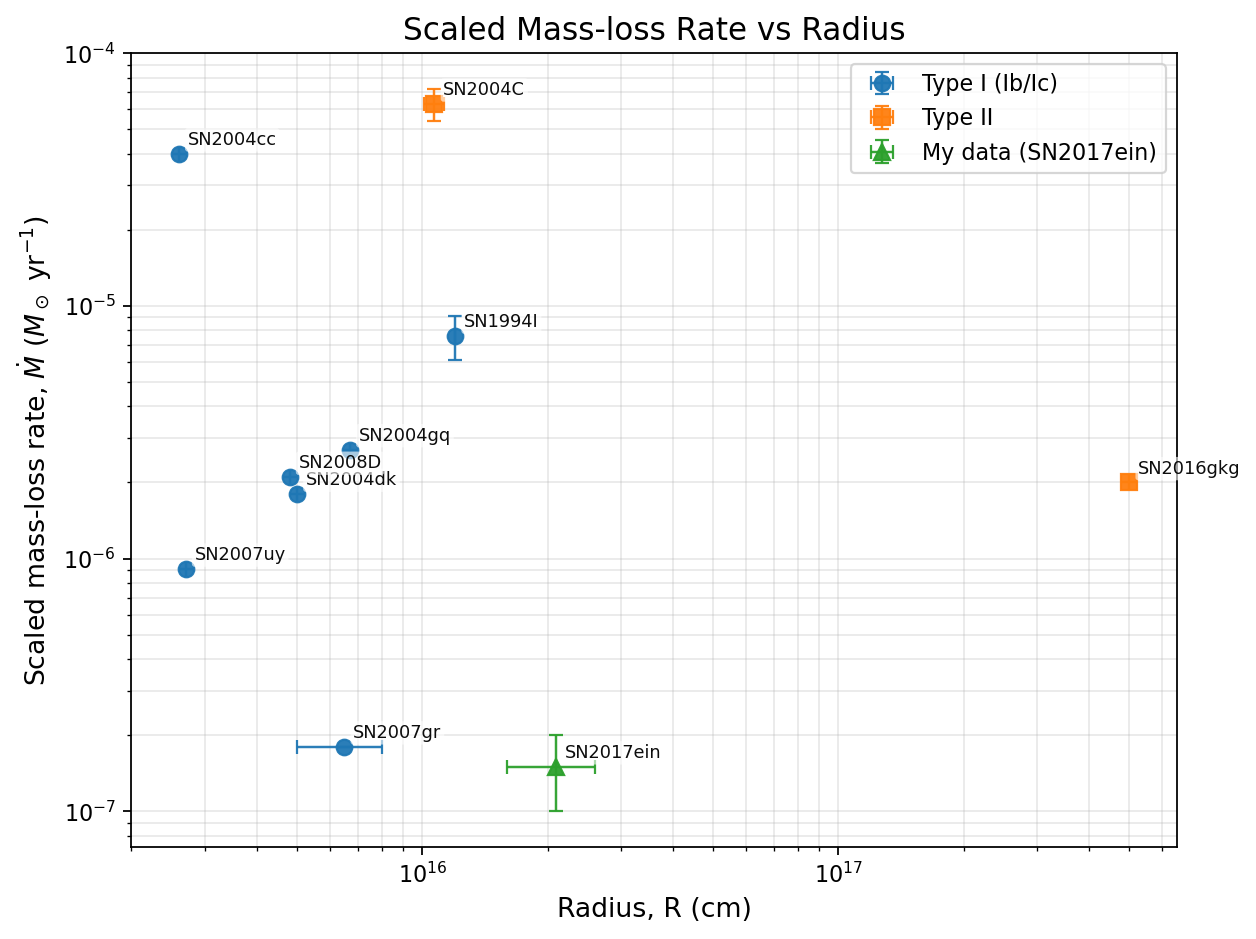

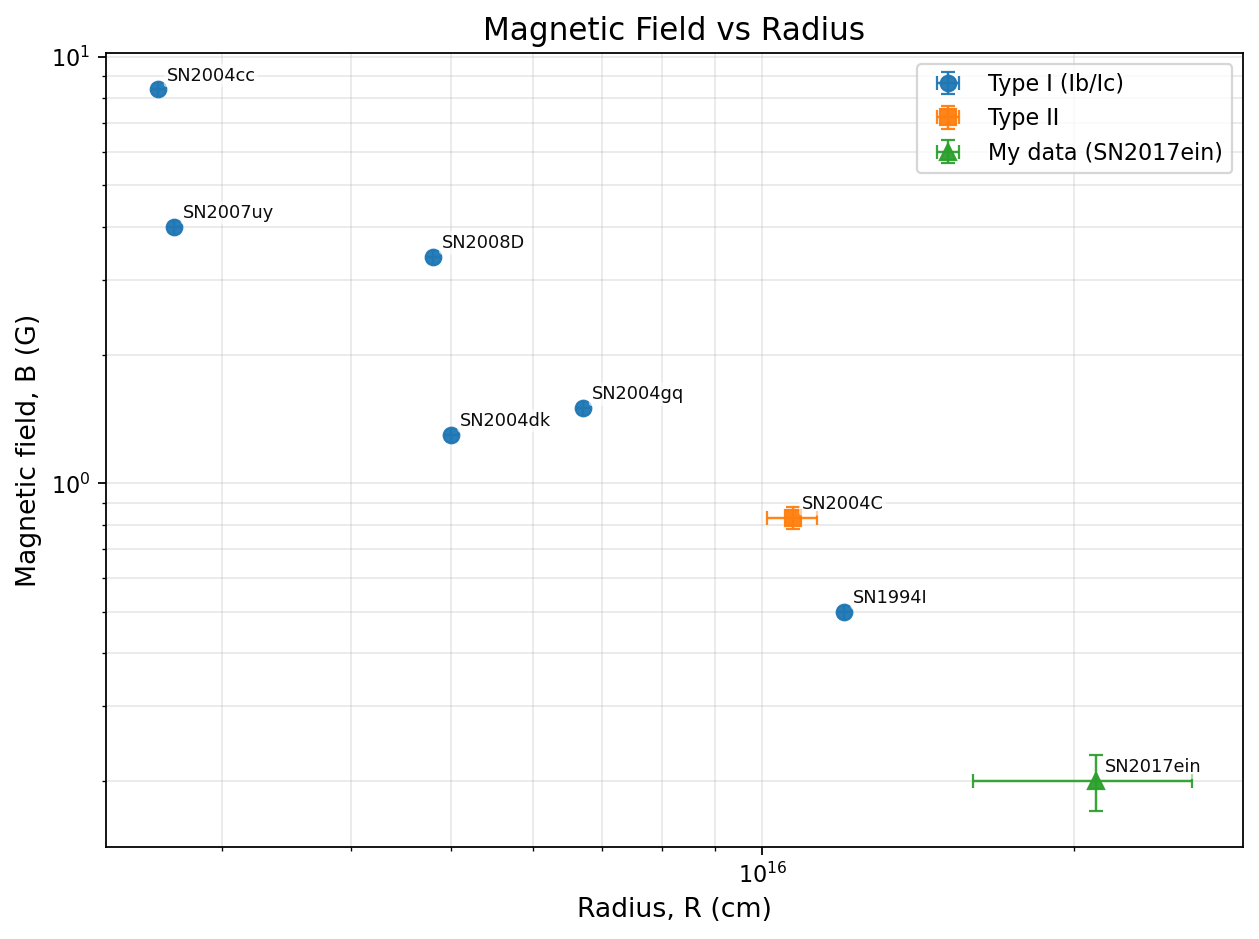

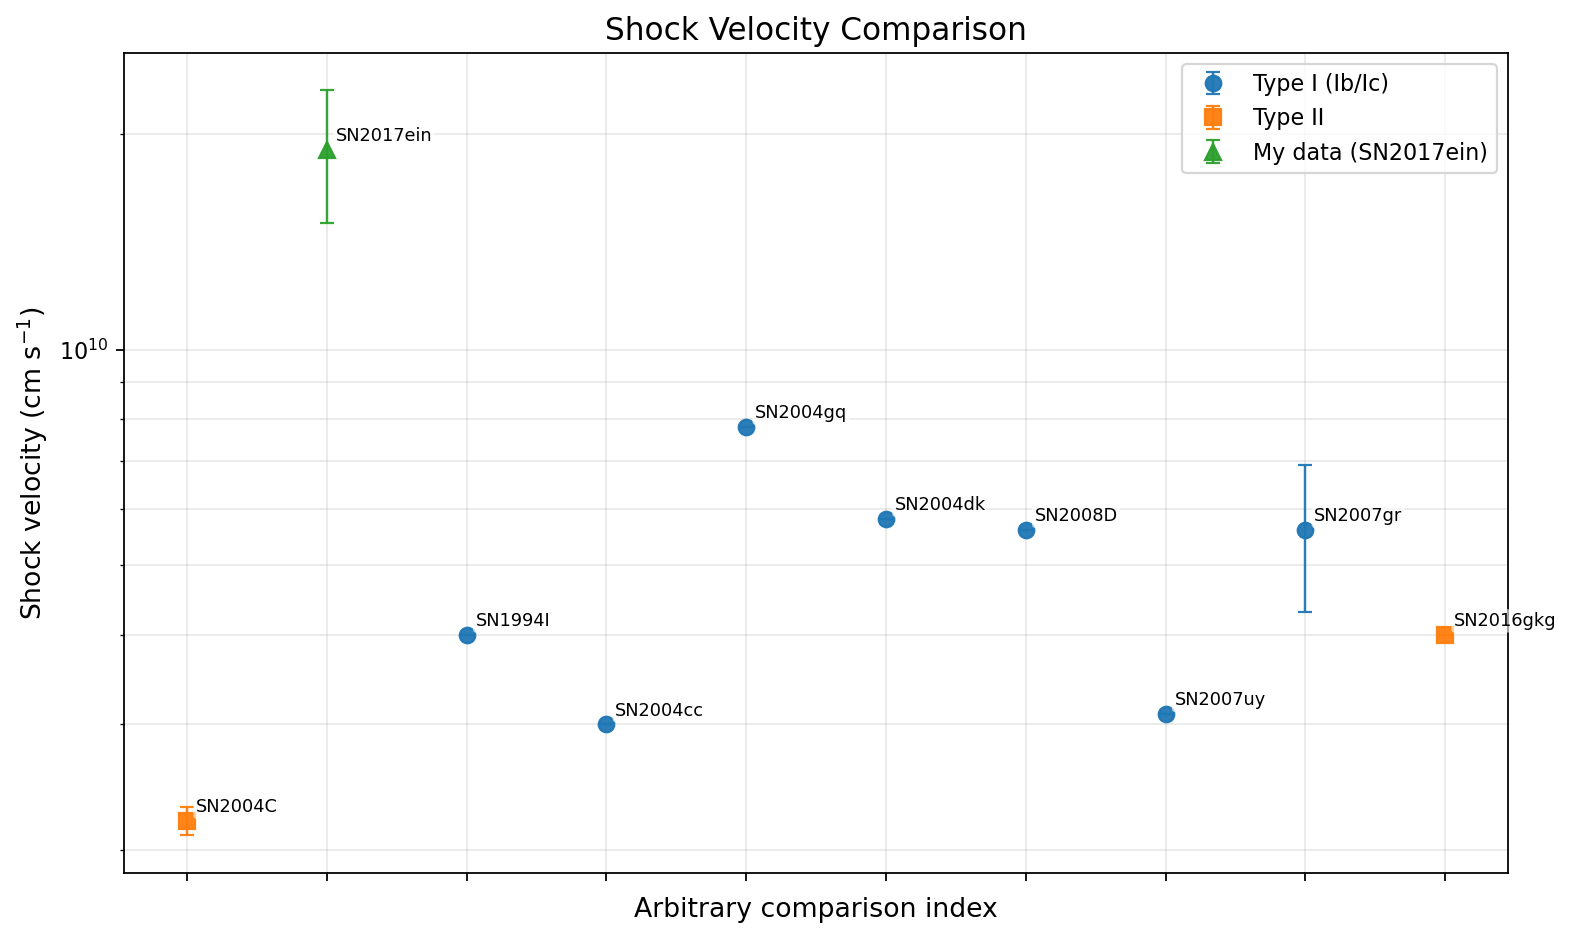

Saved files:
 - density_scaled_vs_radius.png
 - massloss_scaled_vs_radius.png
 - B_vs_radius.png
 - shock_velocity_comparison.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Hard-coded data
# ============================================================

data = [
    # name, class_group, subtype, B, B_err, R, R_err, vshock, vshock_err,
    # rho_scaled, rho_scaled_err, mdot_scaled, mdot_scaled_err

    {
        "name": "SN2004C",
        "group": "Type II",
        "subtype": "IIb",
        "B": 0.83, "B_err": 0.05,
        "R": 1.07e16, "R_err": 0.06e16,
        "vshock": 2.2e9, "vshock_err": 0.1e9,
        "rho_scaled": 2.8e-20, "rho_scaled_err": 0.6e-20,
        "mdot_scaled": 6.3e-5, "mdot_scaled_err": 0.9e-5,
    },
    # SN2004C (0.01, 0.1) excluded on purpose

    {
        "name": "SN2017ein",
        "group": "My Data",
        "subtype": "Ic",
        "B": 0.20, "B_err": 0.03,
        "R": 2.1e16, "R_err": 0.5e16,
        "vshock": 1.9e10, "vshock_err": 0.4e10,
        "rho_scaled": 1.7e-23, "rho_scaled_err": 1.0e-23,
        "mdot_scaled": 1.5e-7, "mdot_scaled_err": 0.5e-7,
    },
    # SN2017ein (0.01, 0.1) excluded on purpose

    {
        "name": "SN1994I",
        "group": "Type I",
        "subtype": "Ic",
        "B": 0.5, "B_err": 0.0,
        "R": 1.2e16, "R_err": 0.0,
        "vshock": 4.0e9, "vshock_err": 0.0,
        "rho_scaled": 2.6e-21, "rho_scaled_err": 0.5e-21,
        "mdot_scaled": 7.6e-6, "mdot_scaled_err": 1.5e-6,
    },
    {
        "name": "SN2004cc",
        "group": "Type I",
        "subtype": "Ic",
        "B": 8.4, "B_err": 0.0,
        "R": 2.6e15, "R_err": 0.0,
        "vshock": 3.0e9, "vshock_err": 0.0,
        "rho_scaled": 2.92e-19, "rho_scaled_err": 0.0,
        "mdot_scaled": 4.0e-5, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2004gq",
        "group": "Type I",
        "subtype": "Ib",
        "B": 1.5, "B_err": 0.0,
        "R": 6.7e15, "R_err": 0.0,
        "vshock": 7.8e9, "vshock_err": 0.0,
        "rho_scaled": 3.0e-21, "rho_scaled_err": 0.0,
        "mdot_scaled": 2.7e-6, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2004dk",
        "group": "Type I",
        "subtype": "Ib",
        "B": 1.3, "B_err": 0.0,
        "R": 5.0e15, "R_err": 0.0,
        "vshock": 5.8e9, "vshock_err": 0.0,
        "rho_scaled": 3.6e-21, "rho_scaled_err": 0.0,
        "mdot_scaled": 1.8e-6, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2008D",
        "group": "Type I",
        "subtype": "Ib",
        "B": 3.4, "B_err": 0.0,
        "R": 4.8e15, "R_err": 0.0,
        "vshock": 5.6e9, "vshock_err": 0.0,
        "rho_scaled": 4.6e-21, "rho_scaled_err": 0.0,
        "mdot_scaled": 2.1e-6, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2007uy",
        "group": "Type I",
        "subtype": "Ib",
        "B": 4.0, "B_err": 0.0,
        "R": 2.7e15, "R_err": 0.0,
        "vshock": 3.1e9, "vshock_err": 0.0,
        "rho_scaled": 6.5e-21, "rho_scaled_err": 0.0,
        "mdot_scaled": 9.1e-7, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2007gr",
        "group": "Type I",
        "subtype": "Ic",
        "B": None, "B_err": 0.0,  # unspecified
        "R": 6.5e15, "R_err": 1.5e15,
        "vshock": 5.6e9, "vshock_err": 1.3e9,
        "rho_scaled": 2.2e-22, "rho_scaled_err": 1.0e-22,
        "mdot_scaled": 1.8e-7, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2020oi",
        "group": "Type I",
        "subtype": "Ic",
        "B": None, "B_err": 0.0,  # unspecified
        "R": 2.0e15, "R_err": 1.0e15,
        "vshock": None, "vshock_err": 0.0,  # unspecified
        "rho_scaled": None, "rho_scaled_err": 0.0,  # unspecified
        "mdot_scaled": None, "mdot_scaled_err": 0.0,  # unspecified
    },
    {
        "name": "SN2016gkg",
        "group": "Type II",
        "subtype": "IIb",
        "B": None, "B_err": 0.0,  # unspecified
        "R": 5.0e17, "R_err": 0.0,
        "vshock": 4.0e9, "vshock_err": 0.0,
        "rho_scaled": 4.01e-24, "rho_scaled_err": 0.0,
        "mdot_scaled": 2.0e-6, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2004dj",
        "group": "Type II",
        "subtype": "IIP",
        "B": None, "B_err": 0.0,  # unspecified
        "R": 3.0e15, "R_err": 1.0e15,
        "vshock": None, "vshock_err": 0.0,  # unspecified
        "rho_scaled": None, "rho_scaled_err": 0.0,  # unspecified
        "mdot_scaled": None, "mdot_scaled_err": 0.0,  # unspecified
    },
]

# ============================================================
# Plot styling
# ============================================================

plt.rcParams.update({
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 160,
})

styles = {
    "Type I": {
        "marker": "o",
        "label": "Type I (Ib/Ic)",
    },
    "Type II": {
        "marker": "s",
        "label": "Type II",
    },
    "My Data": {
        "marker": "^",
        "label": "My data (SN2017ein)",
    },
}

# ============================================================
# Helpers
# ============================================================

def valid_rows(xkey, ykey):
    out = []
    for d in data:
        if d[xkey] is None or d[ykey] is None:
            continue
        out.append(d)
    return out

def annotate_points(ax, rows, xkey, ykey, use_log=True):
    for d in rows:
        x = d[xkey]
        y = d[ykey]

        if use_log:
            # offset slightly in log-space-ish using screen coords
            ax.annotate(
                d["name"],
                xy=(x, y),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.95,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6)
            )
        else:
            ax.annotate(
                d["name"],
                xy=(x, y),
                xytext=(4, 4),
                textcoords="offset points",
                fontsize=8,
                alpha=0.95,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6)
            )

def scatter_with_errors(ax, rows, xkey, ykey, xlabel, ylabel, title,
                        logx=True, logy=True, savefile=None):
    for group in ["Type I", "Type II", "My Data"]:
        group_rows = [d for d in rows if d["group"] == group]
        if not group_rows:
            continue

        x = np.array([d[xkey] for d in group_rows], dtype=float)
        y = np.array([d[ykey] for d in group_rows], dtype=float)
        xerr = np.array([d.get(f"{xkey}_err", 0.0) or 0.0 for d in group_rows], dtype=float)
        yerr = np.array([d.get(f"{ykey}_err", 0.0) or 0.0 for d in group_rows], dtype=float)

        ax.errorbar(
            x, y,
            xerr=xerr, yerr=yerr,
            fmt=styles[group]["marker"],
            markersize=7,
            capsize=3,
            elinewidth=1.1,
            linestyle="None",
            label=styles[group]["label"],
            alpha=0.95
        )

    annotate_points(ax, rows, xkey, ykey, use_log=(logx or logy))

    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.28)
    ax.legend(frameon=True)
    plt.tight_layout()

    if savefile:
        plt.savefig(savefile, bbox_inches="tight")

# ============================================================
# 1. Density scaled vs Radius
# ============================================================

rows = valid_rows("R", "rho_scaled")
fig, ax = plt.subplots(figsize=(8, 6))
scatter_with_errors(
    ax=ax,
    rows=rows,
    xkey="R",
    ykey="rho_scaled",
    xlabel="Radius, R (cm)",
    ylabel=r"Scaled density, $\rho$ (g cm$^{-3}$)",
    title="Scaled CSM Density vs Radius",
    logx=True,
    logy=True,
    savefile="density_scaled_vs_radius.png"
)
plt.show()

# ============================================================
# 2. Mass-loss rate scaled vs Radius
# ============================================================

rows = valid_rows("R", "mdot_scaled")
fig, ax = plt.subplots(figsize=(8, 6))
scatter_with_errors(
    ax=ax,
    rows=rows,
    xkey="R",
    ykey="mdot_scaled",
    xlabel="Radius, R (cm)",
    ylabel=r"Scaled mass-loss rate, $\dot{M}$ ($M_\odot$ yr$^{-1}$)",
    title="Scaled Mass-loss Rate vs Radius",
    logx=True,
    logy=True,
    savefile="massloss_scaled_vs_radius.png"
)
plt.show()

# ============================================================
# 3. Magnetic field B vs Radius
# ============================================================

rows = valid_rows("R", "B")
fig, ax = plt.subplots(figsize=(8, 6))
scatter_with_errors(
    ax=ax,
    rows=rows,
    xkey="R",
    ykey="B",
    xlabel="Radius, R (cm)",
    ylabel="Magnetic field, B (G)",
    title="Magnetic Field vs Radius",
    logx=True,
    logy=True,
    savefile="B_vs_radius.png"
)
plt.show()

# ============================================================
# 4. Shock velocity vs arbitrary axis
# ============================================================

rows = [d for d in data if d["vshock"] is not None]

# arbitrary x positions just for comparison
x_positions = np.arange(len(rows))

fig, ax = plt.subplots(figsize=(10, 6))

for group in ["Type I", "Type II", "My Data"]:
    idx = [i for i, d in enumerate(rows) if d["group"] == group]
    if not idx:
        continue

    x = x_positions[idx]
    y = np.array([rows[i]["vshock"] for i in idx], dtype=float)
    yerr = np.array([rows[i].get("vshock_err", 0.0) or 0.0 for i in idx], dtype=float)

    ax.errorbar(
        x, y,
        yerr=yerr,
        fmt=styles[group]["marker"],
        markersize=7,
        capsize=3,
        elinewidth=1.1,
        linestyle="None",
        label=styles[group]["label"],
        alpha=0.95
    )

for i, d in enumerate(rows):
    ax.annotate(
        d["name"],
        xy=(x_positions[i], d["vshock"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6)
    )

ax.set_yscale("log")
ax.set_xlabel("Arbitrary comparison index")
ax.set_ylabel(r"Shock velocity (cm s$^{-1}$)")
ax.set_title("Shock Velocity Comparison")
ax.grid(True, which="both", alpha=0.28)
ax.legend(frameon=True)

# optional: remove x tick labels since axis is arbitrary
ax.set_xticks(x_positions)
ax.set_xticklabels([""] * len(x_positions))

plt.tight_layout()
plt.savefig("shock_velocity_comparison.png", bbox_inches="tight")
plt.show()

print("Saved files:")
print(" - density_scaled_vs_radius.png")
print(" - massloss_scaled_vs_radius.png")
print(" - B_vs_radius.png")
print(" - shock_velocity_comparison.png")

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Hard-coded data from your updated table
# ============================================================

data = [
# name, class_group, subtype, B, B_err, R, R_err, vshock, vshock_err,
# rho_scaled, rho_scaled_err, mdot_scaled, mdot_scaled_err

{
"name": "SN2004C",
"group": "Type II",
"subtype": "IIb",
"B": 0.83, "B_err": 0.05,
"R": 1.07e16, "R_err": 0.06e16,
"vshock": 2.2e9, "vshock_err": 0.1e9,
"rho_scaled": 2.8e-20, "rho_scaled_err": 0.6e-20,
"mdot_scaled": 6.3e-5, "mdot_scaled_err": 0.9e-5,
},
# SN2004C (0.01, 0.1) excluded on purpose

{
"name": "SN2017ein",
"group": "My Data",
"subtype": "Ic",
"B": 0.20, "B_err": 0.03,
"R": 2.1e16, "R_err": 0.5e16,
"vshock": 1.9e10, "vshock_err": 0.4e10,
"rho_scaled": 1.7e-22, "rho_scaled_err": 1.0e-22,
"mdot_scaled": 1.5e-7, "mdot_scaled_err": 0.5e-7,
},
# SN2017ein (0.01, 0.1) excluded on purpose

{
"name": "SN1994I",
"group": "Type I",
"subtype": "Ic",
"B": 0.5, "B_err": 0.0,
"R": 1.2e16, "R_err": 0.0,
"vshock": 4.0e9, "vshock_err": 0.0,
"rho_scaled": 2.6e-21, "rho_scaled_err": 0.5e-21,
"mdot_scaled": 7.6e-6, "mdot_scaled_err": 1.5e-6,
},
{
"name": "SN2004cc",
"group": "Type I",
"subtype": "Ic",
"B": 8.4, "B_err": 0.0,
"R": 2.6e15, "R_err": 0.0,
"vshock": 3.0e9, "vshock_err": 0.0,
"rho_scaled": 2.92e-19, "rho_scaled_err": 0.0,
"mdot_scaled": 4.0e-5, "mdot_scaled_err": 0.0,
},
{
"name": "SN2004gq",
"group": "Type I",
"subtype": "Ib",
"B": 1.5, "B_err": 0.0,
"R": 6.7e15, "R_err": 0.0,
"vshock": 7.8e9, "vshock_err": 0.0,
"rho_scaled": 3.0e-21, "rho_scaled_err": 0.0,
"mdot_scaled": 2.7e-6, "mdot_scaled_err": 0.0,
},
{
"name": "SN2004dk",
"group": "Type I",
"subtype": "Ib",
"B": 1.3, "B_err": 0.0,
"R": 5.0e15, "R_err": 0.0,
"vshock": 5.8e9, "vshock_err": 0.0,
"rho_scaled": 3.6e-21, "rho_scaled_err": 0.0,
"mdot_scaled": 1.8e-6, "mdot_scaled_err": 0.0,
},
{
"name": "SN2008D",
"group": "Type I",
"subtype": "Ib",
"B": 3.4, "B_err": 0.0,
"R": 4.8e15, "R_err": 0.0,
"vshock": 5.6e9, "vshock_err": 0.0,
"rho_scaled": 4.6e-21, "rho_scaled_err": 0.0,
"mdot_scaled": 2.1e-6, "mdot_scaled_err": 0.0,
},
{
"name": "SN2007uy",
"group": "Type I",
"subtype": "Ib",
"B": 4.0, "B_err": 0.0,
"R": 2.7e15, "R_err": 0.0,
"vshock": 3.1e9, "vshock_err": 0.0,
"rho_scaled": 6.5e-21, "rho_scaled_err": 0.0,
"mdot_scaled": 9.1e-7, "mdot_scaled_err": 0.0,
},
{
"name": "SN2007gr",
"group": "Type I",
"subtype": "Ic",
"B": None, "B_err": 0.0, # unspecified
"R": 6.5e15, "R_err": 1.5e15,
"vshock": 5.6e9, "vshock_err": 1.3e9,
"rho_scaled": 2.2e-22, "rho_scaled_err": 1.0e-22,
"mdot_scaled": 1.8e-7, "mdot_scaled_err": 0.0,
},
{
"name": "SN2020oi",
"group": "Type I",
"subtype": "Ic",
"B": None, "B_err": 0.0, # unspecified
"R": 2.0e15, "R_err": 1.0e15,
"vshock": None, "vshock_err": 0.0, # unspecified
"rho_scaled": None, "rho_scaled_err": 0.0, # unspecified
"mdot_scaled": None, "mdot_scaled_err": 0.0, # unspecified
},
{
"name": "SN2016gkg",
"group": "Type II",
"subtype": "IIb",
"B": None, "B_err": 0.0, # unspecified
"R": 5.0e17, "R_err": 0.0,
"vshock": 4.0e9, "vshock_err": 0.0,
"rho_scaled": 4.01e-24, "rho_scaled_err": 0.0,
"mdot_scaled": 2.0e-6, "mdot_scaled_err": 0.0,
},
{
"name": "SN2004dj",
"group": "Type II",
"subtype": "IIP",
"B": None, "B_err": 0.0, # unspecified
"R": 3.0e15, "R_err": 1.0e15,
"vshock": None, "vshock_err": 0.0, # unspecified
"rho_scaled": None, "rho_scaled_err": 0.0, # unspecified
"mdot_scaled": None, "mdot_scaled_err": 0.0, # unspecified
},
]

# ============================================================
# Plot styling
# ============================================================

plt.rcParams.update({
"font.size": 11,
"axes.labelsize": 12,
"axes.titlesize": 14,
"legend.fontsize": 10,
"xtick.labelsize": 10,
"ytick.labelsize": 10,
"figure.dpi": 160,
})

styles = {
"Type I": {
"marker": "o",
"label": "Type I (Ib/Ic)",
},
"Type II": {
"marker": "s",
"label": "Type II",
},
"My Data": {
"marker": "^",
"label": "My data (SN2017ein)",
},
}

# ============================================================
# Helpers
# ============================================================

def valid_rows(xkey, ykey):
out = []
for d in data:
    
if d[xkey] is None or d[ykey] is None:
continue
out.append(d)
return out

def annotate_points(ax, rows, xkey, ykey, use_log=True):
for d in rows:
x = d[xkey]
y = d[ykey]

if use_log:
# offset slightly in log-space-ish using screen coords
ax.annotate(
d["name"],
xy=(x, y),
xytext=(4, 4),
textcoords="offset points",
fontsize=8,
alpha=0.95,
bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6)
)
else:
ax.annotate(
d["name"],
xy=(x, y),
xytext=(4, 4),
textcoords="offset points",
fontsize=8,
alpha=0.95,
bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6)
)

def scatter_with_errors(ax, rows, xkey, ykey, xlabel, ylabel, title,
logx=True, logy=True, savefile=None):
for group in ["Type I", "Type II", "My Data"]:
group_rows = [d for d in rows if d["group"] == group]
if not group_rows:
continue

x = np.array([d[xkey] for d in group_rows], dtype=float)
y = np.array([d[ykey] for d in group_rows], dtype=float)
xerr = np.array([d.get(f"{xkey}_err", 0.0) or 0.0 for d in group_rows], dtype=float)
yerr = np.array([d.get(f"{ykey}_err", 0.0) or 0.0 for d in group_rows], dtype=float)

ax.errorbar(
x, y,
xerr=xerr, yerr=yerr,
fmt=styles[group]["marker"],
markersize=7,
capsize=3,
elinewidth=1.1,
linestyle="None",
label=styles[group]["label"],
alpha=0.95
)

annotate_points(ax, rows, xkey, ykey, use_log=(logx or logy))

if logx:
ax.set_xscale("log")
if logy:
ax.set_yscale("log")

ax.set_xlabel(xlabel)
ax.set_ylabel(ylabel)
ax.set_title(title)
ax.grid(True, which="both", alpha=0.28)
ax.legend(frameon=True)
plt.tight_layout()

if savefile:
plt.savefig(savefile, bbox_inches="tight")

# ============================================================
# 1. Density scaled vs Radius
# ============================================================

rows = valid_rows("R", "rho_scaled")
fig, ax = plt.subplots(figsize=(8, 6))

scatter_with_errors(
ax=ax,
rows=rows,
xkey="R",
ykey="rho_scaled",
xlabel="Radius, R (cm)",
ylabel=r"Scaled density, $\rho$ (g cm$^{-3}$)",
title="Scaled CSM Density vs Radius",
logx=True,
logy=True,
)

# ------------------------------------------------------------
# Add rho ∝ r^-2 wind profiles
# ------------------------------------------------------------

MSUN = 1.98847e33
YR = 3.15576e7
vw = 1000e5 # 1000 km/s in cm/s

# radius range spanning data
r_vals = np.logspace(
np.log10(min([d["R"] for d in rows])) - 0.3,
np.log10(max([d["R"] for d in rows])) + 0.3,
300
)

# Mass-loss rates from 10^-4 to 10^-7
mdot_list = [1e-4, 1e-5, 1e-6, 1e-7]

for mdot in mdot_list:

mdot_cgs = mdot * MSUN / YR

rho_vals = mdot_cgs / (4 * np.pi * vw * r_vals**2)

exponent = int(np.log10(mdot))

ax.plot(
r_vals,
rho_vals,
linestyle="--",
linewidth=1.8,
label=rf"$\dot{{M}} = 10^{{{exponent}}}\,M_\odot\,\mathrm{{yr}}^{{-1}},\ v_w = 1000\ \mathrm{{km\,s^{{-1}}}}$"
)

# Smaller legend
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("density_scaled_vs_radius.png", bbox_inches="tight")
plt.show()

# ============================================================
# 2. Mass-loss rate scaled vs Radius
# ============================================================

rows = valid_rows("R", "mdot_scaled")
fig, ax = plt.subplots(figsize=(8, 6))
scatter_with_errors(
ax=ax,
rows=rows,
xkey="R",
ykey="mdot_scaled",
xlabel="Radius, R (cm)",
ylabel=r"Scaled mass-loss rate, $\dot{M}$ ($M_\odot$ yr$^{-1}$)",
title="Scaled Mass-loss Rate vs Radius",
logx=True,
logy=True,
savefile="massloss_scaled_vs_radius.png"
)
plt.show()

# ============================================================
# 3. Magnetic field B vs Radius
# ============================================================

rows = valid_rows("R", "B")
fig, ax = plt.subplots(figsize=(8, 6))
scatter_with_errors(
ax=ax,
rows=rows,
xkey="R",
ykey="B",
xlabel="Radius, R (cm)",
ylabel="Magnetic field, B (G)",
title="Magnetic Field vs Radius",
logx=True,
logy=True,
savefile="B_vs_radius.png"
)
plt.show()

# ============================================================
# 4. Shock velocity vs arbitrary axis
# ============================================================

rows = [d for d in data if d["vshock"] is not None]

# arbitrary x positions just for comparison
x_positions = np.arange(len(rows))

fig, ax = plt.subplots(figsize=(10, 6))

for group in ["Type I", "Type II", "My Data"]:
idx = [i for i, d in enumerate(rows) if d["group"] == group]
if not idx:
continue

x = x_positions[idx]
y = np.array([rows[i]["vshock"] for i in idx], dtype=float)
yerr = np.array([rows[i].get("vshock_err", 0.0) or 0.0 for i in idx], dtype=float)

ax.errorbar(
x, y,
yerr=yerr,
fmt=styles[group]["marker"],
markersize=7,
capsize=3,
elinewidth=1.1,
linestyle="None",
label=styles[group]["label"],
alpha=0.95
)

for i, d in enumerate(rows):
ax.annotate(
d["name"],
xy=(x_positions[i], d["vshock"]),
xytext=(4, 4),
textcoords="offset points",
fontsize=8,
bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.6)
)

ax.set_yscale("log")
ax.set_xlabel("Supernova Sample")
ax.set_ylabel(r"Shock velocity (cm s$^{-1}$)")
ax.set_title("Shock Velocity Comparison")
ax.grid(True, which="both", alpha=0.28)
ax.legend(frameon=True)

# optional: remove x tick labels since axis is arbitrary
ax.set_xticks(x_positions)
ax.set_xticklabels([""] * len(x_positions))

plt.tight_layout()
plt.savefig("shock_velocity_comparison.png", bbox_inches="tight")
plt.show()

print("Saved files:")
print(" - density_scaled_vs_radius.png")
print(" - massloss_scaled_vs_radius.png")
print(" - B_vs_radius.png")
print(" - shock_velocity_comparison.png")


IndentationError: expected an indented block after function definition on line 171 (4266308824.py, line 172)

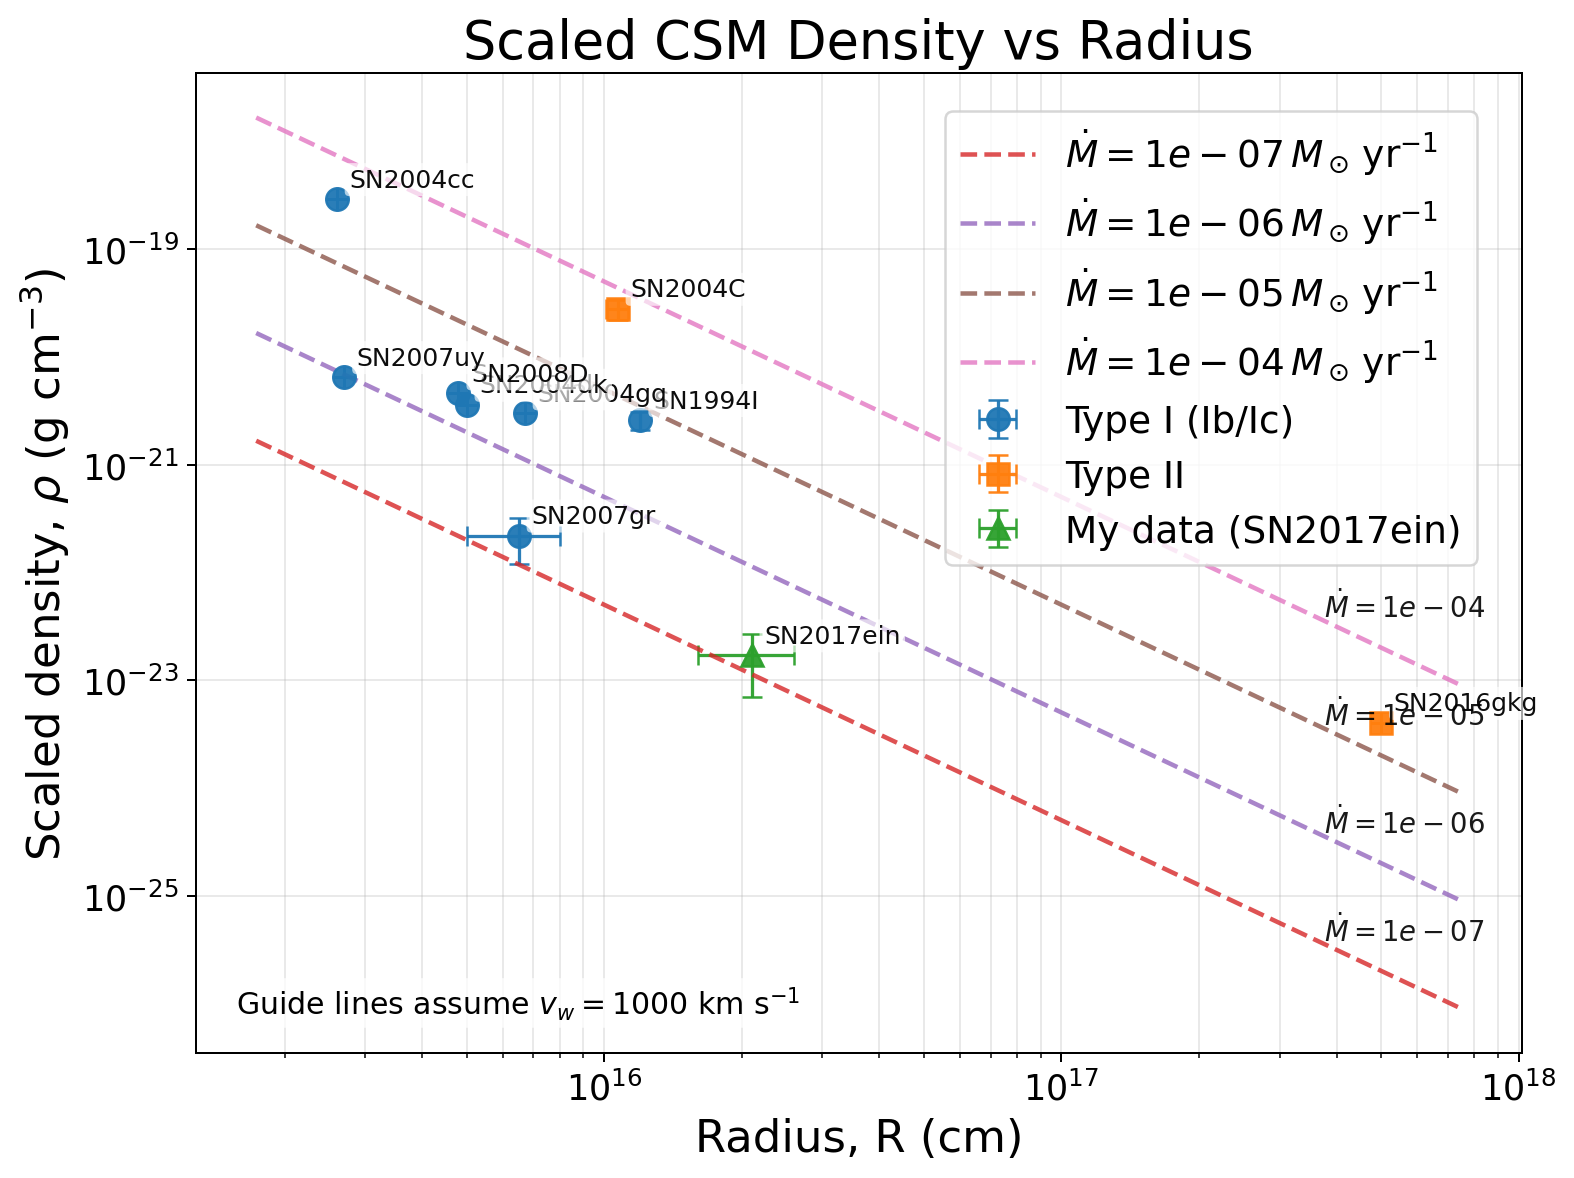

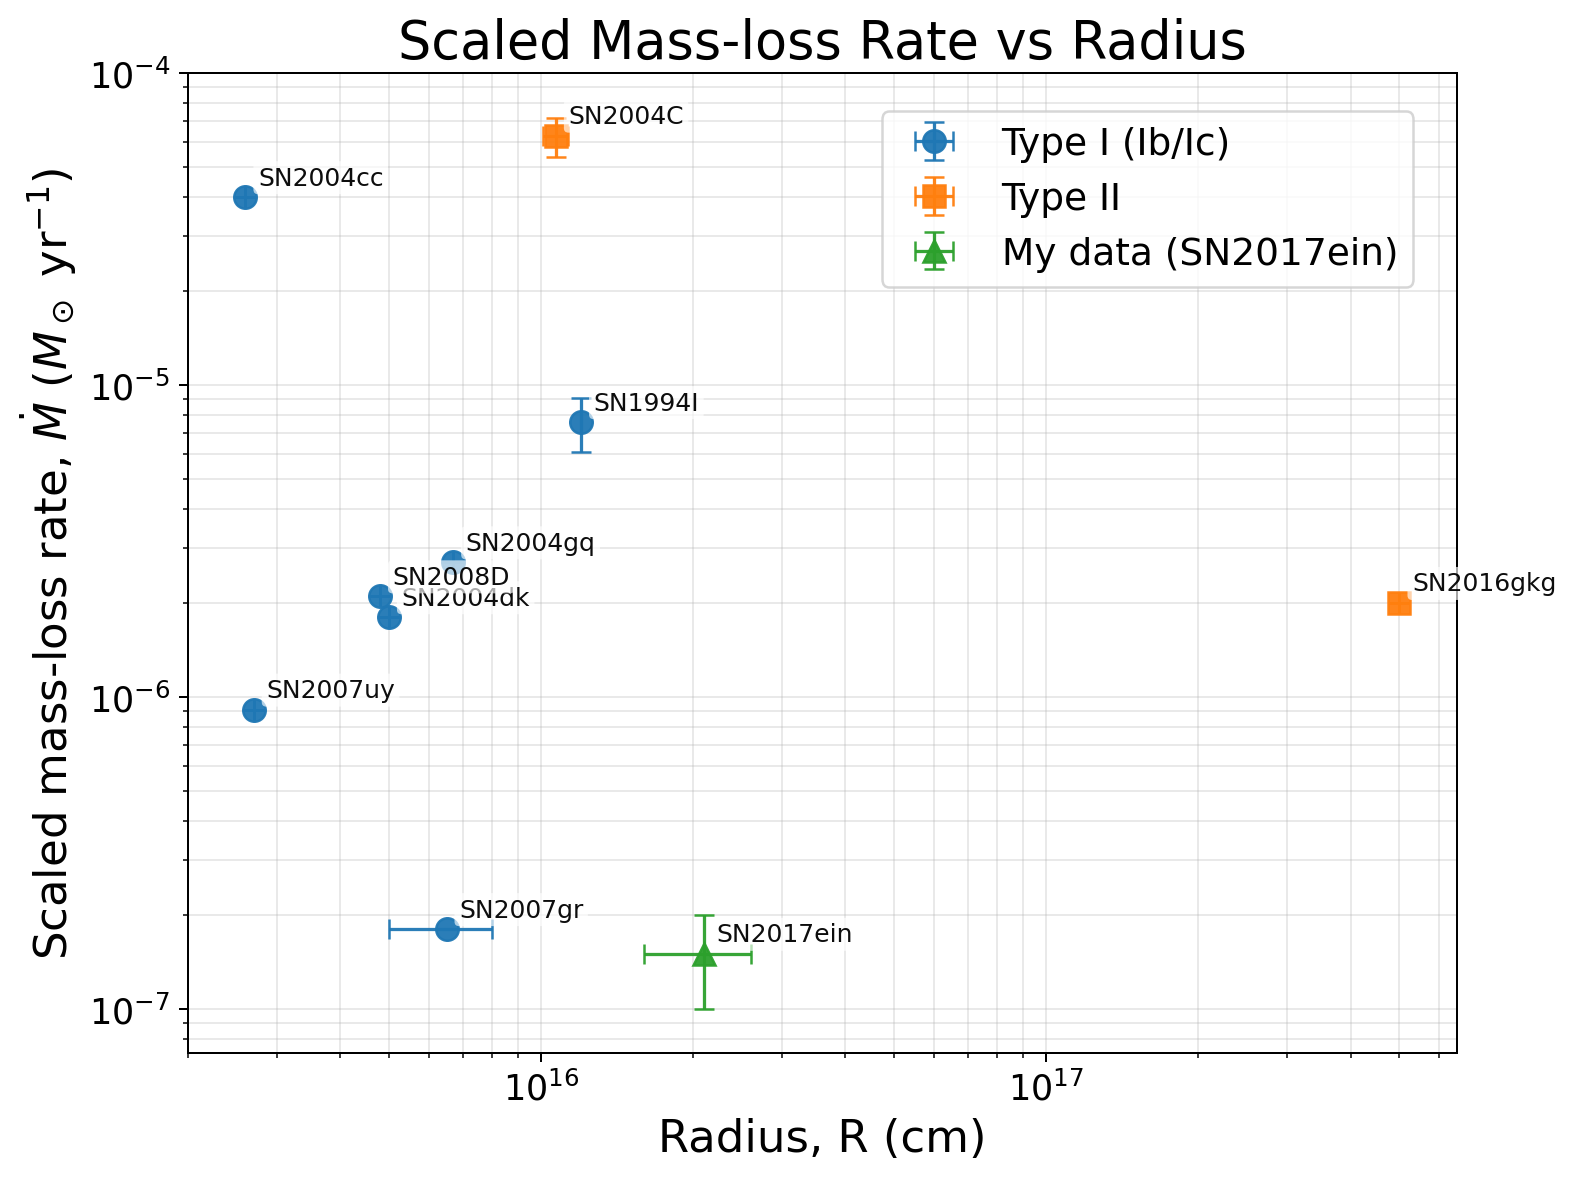

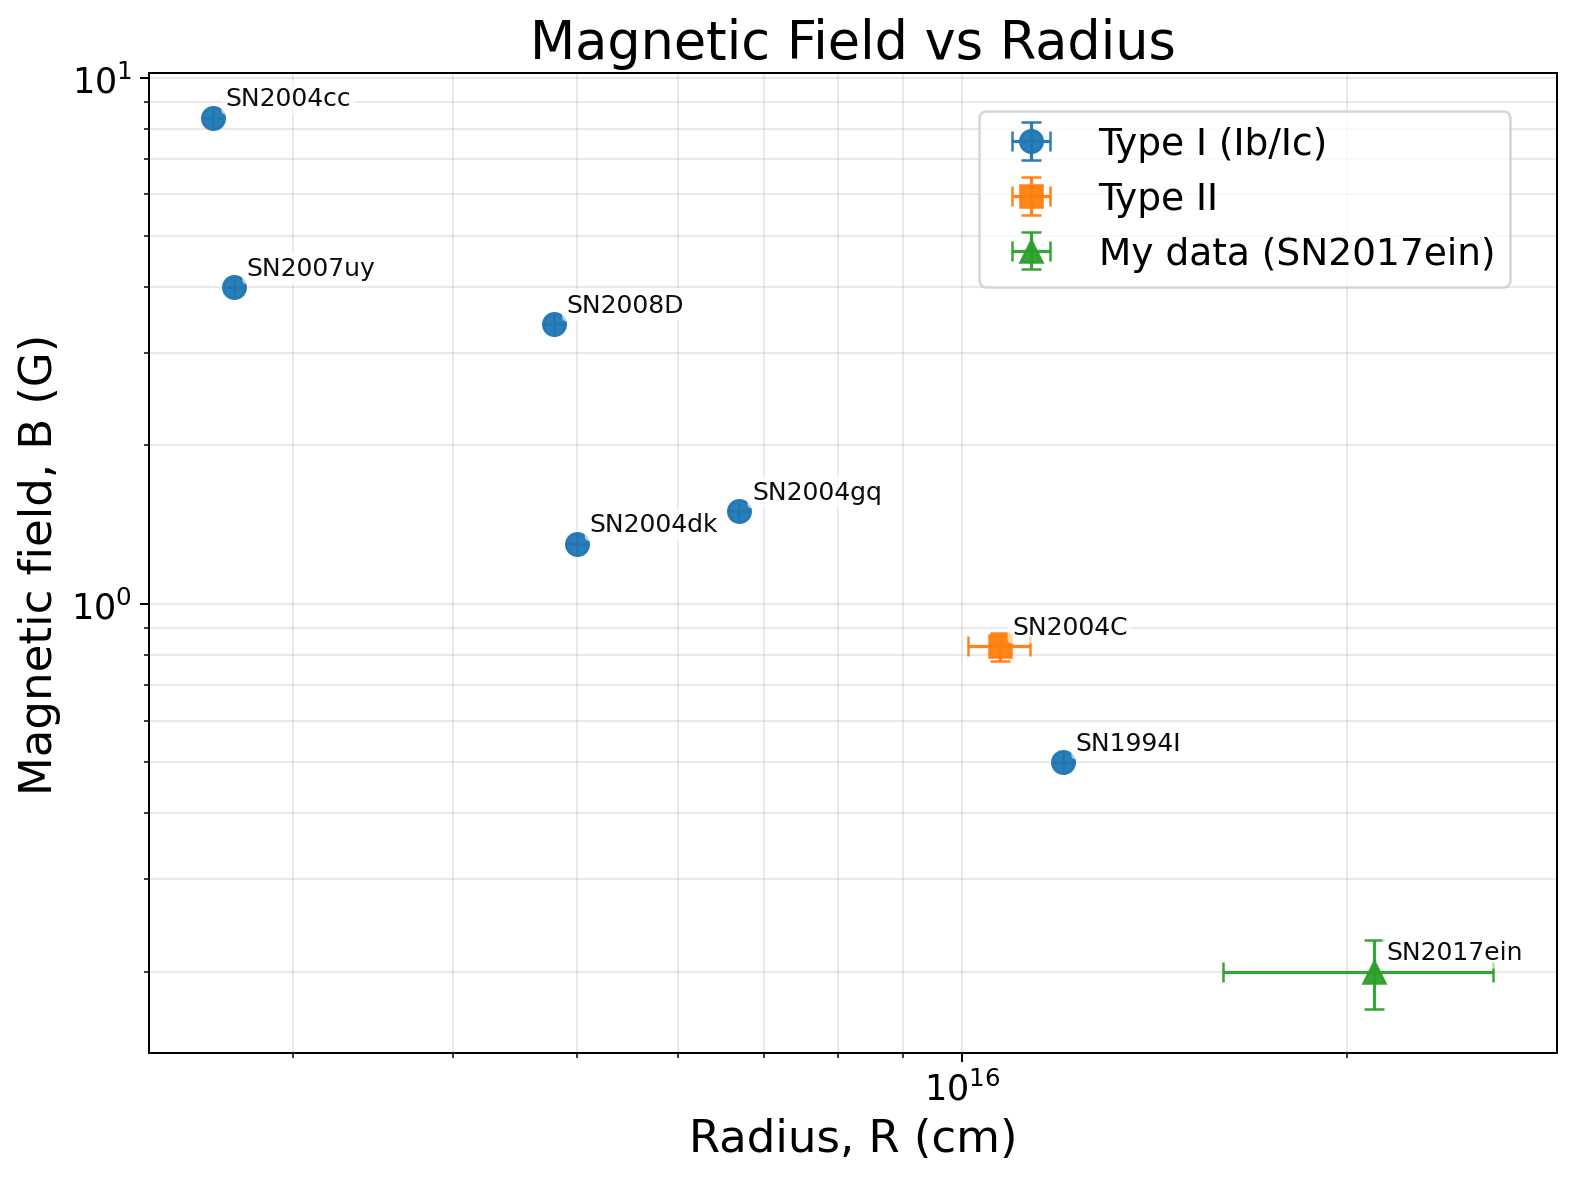

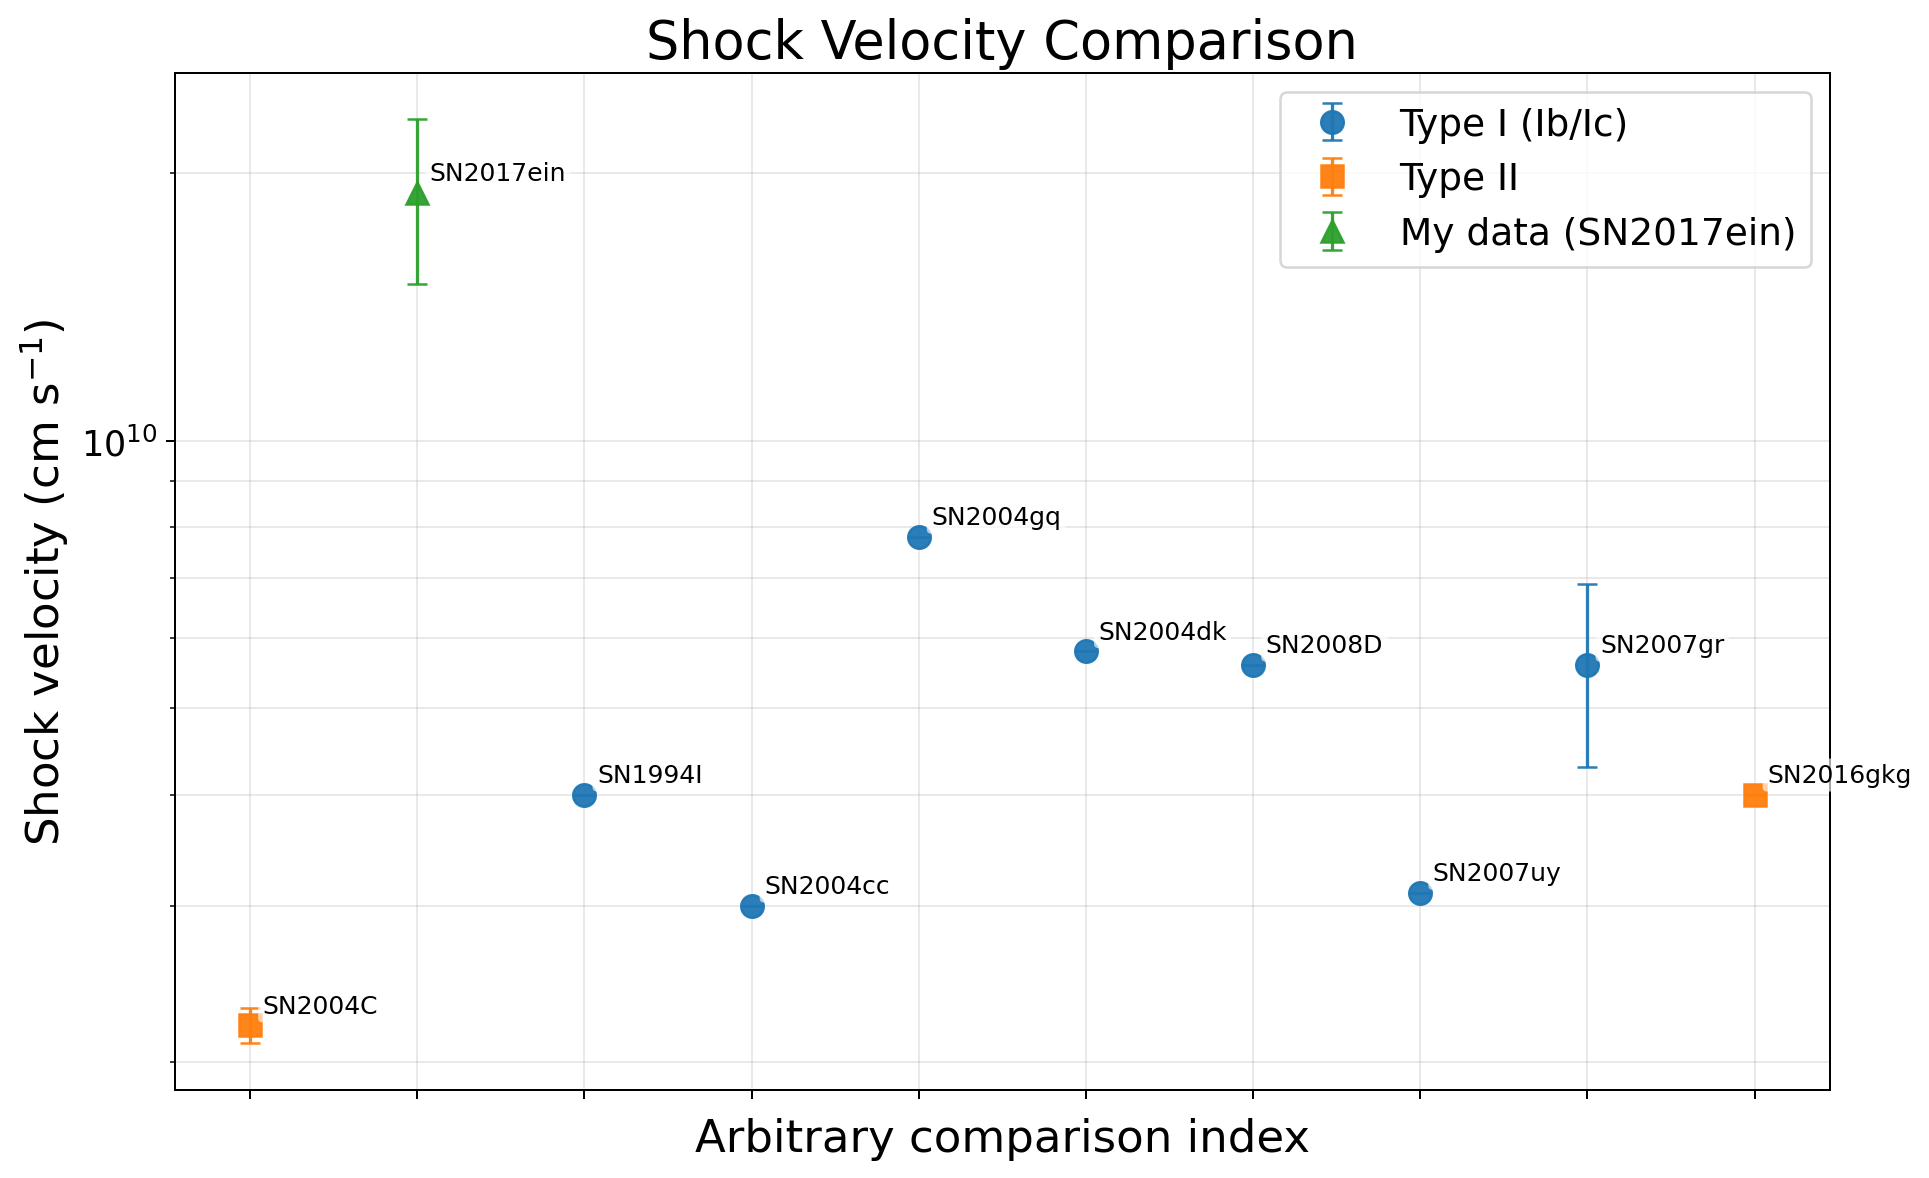

Saved files:
 - density_scaled_vs_radius.png
 - massloss_scaled_vs_radius.png
 - B_vs_radius.png
 - shock_velocity_comparison.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Hard-coded data
# ============================================================

data = [
    # name, class_group, subtype, B, B_err, R, R_err, vshock, vshock_err,
    # rho_scaled, rho_scaled_err, mdot_scaled, mdot_scaled_err

    {
        "name": "SN2004C",
        "group": "Type II",
        "subtype": "IIb",
        "B": 0.83, "B_err": 0.05,
        "R": 1.07e16, "R_err": 0.06e16,
        "vshock": 2.2e9, "vshock_err": 0.1e9,
        "rho_scaled": 2.8e-20, "rho_scaled_err": 0.6e-20,
        "mdot_scaled": 6.3e-5, "mdot_scaled_err": 0.9e-5,
    },

    {
        "name": "SN2017ein",
        "group": "My Data",
        "subtype": "Ic",
        "B": 0.20, "B_err": 0.03,
        "R": 2.1e16, "R_err": 0.5e16,
        "vshock": 1.9e10, "vshock_err": 0.4e10,
        "rho_scaled": 1.7e-23, "rho_scaled_err": 1.0e-23,
        "mdot_scaled": 1.5e-7, "mdot_scaled_err": 0.5e-7,
    },

    {
        "name": "SN1994I",
        "group": "Type I",
        "subtype": "Ic",
        "B": 0.5, "B_err": 0.0,
        "R": 1.2e16, "R_err": 0.0,
        "vshock": 4.0e9, "vshock_err": 0.0,
        "rho_scaled": 2.6e-21, "rho_scaled_err": 0.5e-21,
        "mdot_scaled": 7.6e-6, "mdot_scaled_err": 1.5e-6,
    },
    {
        "name": "SN2004cc",
        "group": "Type I",
        "subtype": "Ic",
        "B": 8.4, "B_err": 0.0,
        "R": 2.6e15, "R_err": 0.0,
        "vshock": 3.0e9, "vshock_err": 0.0,
        "rho_scaled": 2.92e-19, "rho_scaled_err": 0.0,
        "mdot_scaled": 4.0e-5, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2004gq",
        "group": "Type I",
        "subtype": "Ib",
        "B": 1.5, "B_err": 0.0,
        "R": 6.7e15, "R_err": 0.0,
        "vshock": 7.8e9, "vshock_err": 0.0,
        "rho_scaled": 3.0e-21, "rho_scaled_err": 0.0,
        "mdot_scaled": 2.7e-6, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2004dk",
        "group": "Type I",
        "subtype": "Ib",
        "B": 1.3, "B_err": 0.0,
        "R": 5.0e15, "R_err": 0.0,
        "vshock": 5.8e9, "vshock_err": 0.0,
        "rho_scaled": 3.6e-21, "rho_scaled_err": 0.0,
        "mdot_scaled": 1.8e-6, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2008D",
        "group": "Type I",
        "subtype": "Ib",
        "B": 3.4, "B_err": 0.0,
        "R": 4.8e15, "R_err": 0.0,
        "vshock": 5.6e9, "vshock_err": 0.0,
        "rho_scaled": 4.6e-21, "rho_scaled_err": 0.0,
        "mdot_scaled": 2.1e-6, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2007uy",
        "group": "Type I",
        "subtype": "Ib",
        "B": 4.0, "B_err": 0.0,
        "R": 2.7e15, "R_err": 0.0,
        "vshock": 3.1e9, "vshock_err": 0.0,
        "rho_scaled": 6.5e-21, "rho_scaled_err": 0.0,
        "mdot_scaled": 9.1e-7, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2007gr",
        "group": "Type I",
        "subtype": "Ic",
        "B": None, "B_err": 0.0,
        "R": 6.5e15, "R_err": 1.5e15,
        "vshock": 5.6e9, "vshock_err": 1.3e9,
        "rho_scaled": 2.2e-22, "rho_scaled_err": 1.0e-22,
        "mdot_scaled": 1.8e-7, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2020oi",
        "group": "Type I",
        "subtype": "Ic",
        "B": None, "B_err": 0.0,
        "R": 2.0e15, "R_err": 1.0e15,
        "vshock": None, "vshock_err": 0.0,
        "rho_scaled": None, "rho_scaled_err": 0.0,
        "mdot_scaled": None, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2016gkg",
        "group": "Type II",
        "subtype": "IIb",
        "B": None, "B_err": 0.0,
        "R": 5.0e17, "R_err": 0.0,
        "vshock": 4.0e9, "vshock_err": 0.0,
        "rho_scaled": 4.01e-24, "rho_scaled_err": 0.0,
        "mdot_scaled": 2.0e-6, "mdot_scaled_err": 0.0,
    },
    {
        "name": "SN2004dj",
        "group": "Type II",
        "subtype": "IIP",
        "B": None, "B_err": 0.0,
        "R": 3.0e15, "R_err": 1.0e15,
        "vshock": None, "vshock_err": 0.0,
        "rho_scaled": None, "rho_scaled_err": 0.0,
        "mdot_scaled": None, "mdot_scaled_err": 0.0,
    },
]

# ============================================================
# Plot styling -- larger text
# ============================================================

plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 18,
    "axes.titlesize": 21,
    "legend.fontsize": 15,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "figure.dpi": 180,
})

styles = {
    "Type I": {
        "marker": "o",
        "label": "Type I (Ib/Ic)",
    },
    "Type II": {
        "marker": "s",
        "label": "Type II",
    },
    "My Data": {
        "marker": "^",
        "label": "My data (SN2017ein)",
    },
}

# ============================================================
# Helpers
# ============================================================

def valid_rows(xkey, ykey):
    out = []
    for d in data:
        if d[xkey] is None or d[ykey] is None:
            continue
        out.append(d)
    return out

def annotate_points(ax, rows, xkey, ykey):
    for d in rows:
        x = d[xkey]
        y = d[ykey]
        ax.annotate(
            d["name"],
            xy=(x, y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=10,
            alpha=0.95,
            bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.65)
        )

def add_density_reference_lines(ax, rmin, rmax, wind_velocity_kms=1000.0):
    """
    Add rho = Mdot / (4*pi*r^2*v_w) guide lines for several mass-loss rates.
    Assumes:
        Mdot in Msun/yr
        r in cm
        v_w in km/s
        rho in g/cm^3
    """
    msun_g = 1.98847e33
    sec_per_yr = 365.25 * 24 * 3600
    vw_cms = wind_velocity_kms * 1e5

    radii = np.logspace(np.log10(rmin), np.log10(rmax), 300)

    mdot_values = [1e-7, 1e-6, 1e-5, 1e-4]
    line_styles = ["--", "--", "--", "--"]

    for mdot, ls in zip(mdot_values, line_styles):
        mdot_cgs = mdot * msun_g / sec_per_yr
        rho = mdot_cgs / (4.0 * np.pi * radii**2 * vw_cms)

        ax.plot(
            radii,
            rho,
            linestyle=ls,
            linewidth=1.8,
            alpha=0.8,
            label=rf"$\dot{{M}}={mdot:.0e}\,M_\odot\,\mathrm{{yr}}^{{-1}}$"
        )

        # place label near right-hand side
        xlab = radii[-35]
        ylab = rho[-35]
        ax.text(
            xlab,
            ylab * 1.08,
            rf"$\dot{{M}}={mdot:.0e}$",
            fontsize=11,
            alpha=0.9
        )

    # optional note for wind speed
    ax.text(
        0.03, 0.04,
        rf"Guide lines assume $v_w = {int(wind_velocity_kms)}$ km s$^{{-1}}$",
        transform=ax.transAxes,
        fontsize=12,
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.75)
    )

def scatter_with_errors(ax, rows, xkey, ykey, xlabel, ylabel, title,
                        logx=True, logy=True, savefile=None,
                        add_density_lines=False):
    for group in ["Type I", "Type II", "My Data"]:
        group_rows = [d for d in rows if d["group"] == group]
        if not group_rows:
            continue

        x = np.array([d[xkey] for d in group_rows], dtype=float)
        y = np.array([d[ykey] for d in group_rows], dtype=float)
        xerr = np.array([d.get(f"{xkey}_err", 0.0) or 0.0 for d in group_rows], dtype=float)
        yerr = np.array([d.get(f"{ykey}_err", 0.0) or 0.0 for d in group_rows], dtype=float)

        ax.errorbar(
            x, y,
            xerr=xerr, yerr=yerr,
            fmt=styles[group]["marker"],
            markersize=9,
            capsize=4,
            elinewidth=1.3,
            linestyle="None",
            label=styles[group]["label"],
            alpha=0.95
        )

    annotate_points(ax, rows, xkey, ykey)

    if logx:
        ax.set_xscale("log")
    if logy:
        ax.set_yscale("log")

    if add_density_lines:
        all_x = np.array([d[xkey] for d in rows], dtype=float)
        rmin = all_x.min() / 1.5
        rmax = all_x.max() * 1.5
        add_density_reference_lines(ax, rmin, rmax, wind_velocity_kms=1000.0)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, which="both", alpha=0.28)
    ax.legend(frameon=True, loc="upper right", bbox_to_anchor=(0.98, 0.98))
    plt.tight_layout()

    if savefile:
        plt.savefig(savefile, bbox_inches="tight")

# ============================================================
# 1. Density scaled vs Radius
# ============================================================

rows = valid_rows("R", "rho_scaled")
fig, ax = plt.subplots(figsize=(9, 6.8))
scatter_with_errors(
    ax=ax,
    rows=rows,
    xkey="R",
    ykey="rho_scaled",
    xlabel="Radius, R (cm)",
    ylabel=r"Scaled density, $\rho$ (g cm$^{-3}$)",
    title="Scaled CSM Density vs Radius",
    logx=True,
    logy=True,
    savefile="density_scaled_vs_radius.png",
    add_density_lines=True
)
plt.show()

# ============================================================
# 2. Mass-loss rate scaled vs Radius
# ============================================================

rows = valid_rows("R", "mdot_scaled")
fig, ax = plt.subplots(figsize=(9, 6.8))
scatter_with_errors(
    ax=ax,
    rows=rows,
    xkey="R",
    ykey="mdot_scaled",
    xlabel="Radius, R (cm)",
    ylabel=r"Scaled mass-loss rate, $\dot{M}$ ($M_\odot$ yr$^{-1}$)",
    title="Scaled Mass-loss Rate vs Radius",
    logx=True,
    logy=True,
    savefile="massloss_scaled_vs_radius.png"
)
plt.show()

# ============================================================
# 3. Magnetic field B vs Radius
# ============================================================

rows = valid_rows("R", "B")
fig, ax = plt.subplots(figsize=(9, 6.8))
scatter_with_errors(
    ax=ax,
    rows=rows,
    xkey="R",
    ykey="B",
    xlabel="Radius, R (cm)",
    ylabel="Magnetic field, B (G)",
    title="Magnetic Field vs Radius",
    logx=True,
    logy=True,
    savefile="B_vs_radius.png"
)
plt.show()

# ============================================================
# 4. Shock velocity vs arbitrary axis
# ============================================================

rows = [d for d in data if d["vshock"] is not None]
x_positions = np.arange(len(rows))

fig, ax = plt.subplots(figsize=(11, 6.8))

for group in ["Type I", "Type II", "My Data"]:
    idx = [i for i, d in enumerate(rows) if d["group"] == group]
    if not idx:
        continue

    x = x_positions[idx]
    y = np.array([rows[i]["vshock"] for i in idx], dtype=float)
    yerr = np.array([rows[i].get("vshock_err", 0.0) or 0.0 for i in idx], dtype=float)

    ax.errorbar(
        x, y,
        yerr=yerr,
        fmt=styles[group]["marker"],
        markersize=9,
        capsize=4,
        elinewidth=1.3,
        linestyle="None",
        label=styles[group]["label"],
        alpha=0.95
    )

for i, d in enumerate(rows):
    ax.annotate(
        d["name"],
        xy=(x_positions[i], d["vshock"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="none", alpha=0.65)
    )

ax.set_yscale("log")
ax.set_xlabel("Arbitrary comparison index")
ax.set_ylabel(r"Shock velocity (cm s$^{-1}$)")
ax.set_title("Shock Velocity Comparison")
ax.grid(True, which="both", alpha=0.28)
ax.legend(frameon=True)
ax.set_xticks(x_positions)
ax.set_xticklabels([""] * len(x_positions))

plt.tight_layout()
plt.savefig("shock_velocity_comparison.png", bbox_inches="tight")
plt.show()

print("Saved files:")
print(" - density_scaled_vs_radius.png")
print(" - massloss_scaled_vs_radius.png")
print(" - B_vs_radius.png")
print(" - shock_velocity_comparison.png")